So sánh 4 mô hình Machine Learning

In [ ]:
# Cell 1: Import thư viện và khai báo đường dẫn kết quả

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

RESULT_DIR = Path(".")

# Thư mục lưu kết quả so sánh
OUTPUT_DIR = RESULT_DIR / "comparison_results"
OUTPUT_DIR.mkdir(exist_ok=True)

print("Thư mục đọc kết quả:", RESULT_DIR.resolve())
print("Thư mục lưu kết quả so sánh:", OUTPUT_DIR.resolve())


Thư mục đọc kết quả: C:\Users\dungt\Downloads\BCKLTN
Thư mục lưu kết quả so sánh: C:\Users\dungt\Downloads\BCKLTN\comparison_results


In [2]:
# Cell 2: Khai báo tên model và tên file kết quả cần đọc

models = {
    "KNN": {
        "report_files": [
            "KNN_classification_report.csv",
            "knn_classification_report.csv",
            "classification_report_KNN.csv",
            "KNN_report.csv"
        ],
        "confusion_files": [
            "KNN_confusion_matrix.png",
            "knn_confusion_matrix.png",
            "confusion_matrix_KNN.png"
        ]
    },
    "SVM": {
        "report_files": [
            "SVM_classification_report.csv",
            "svm_classification_report.csv",
            "classification_report_SVM.csv",
            "SVM_report.csv"
        ],
        "confusion_files": [
            "SVM_confusion_matrix.png",
            "svm_confusion_matrix.png",
            "confusion_matrix_SVM.png"
        ]
    },
    "Random Forest": {
        "report_files": [
            "Random_forest_classification_report.csv",
            "RandomForest_classification_report.csv",
            "random_forest_classification_report.csv",
            "classification_report_Random_forest.csv",
            "Random_forest_report.csv"
        ],
        "confusion_files": [
            "Random_forest_confusion_matrix.png",
            "RandomForest_confusion_matrix.png",
            "random_forest_confusion_matrix.png",
            "confusion_matrix_Random_forest.png"
        ]
    },
    "Logistic Regression": {
        "report_files": [
            "Logistic_regression_classification_report.csv",
            "LogisticRegression_classification_report.csv",
            "logistic_regression_classification_report.csv",
            "classification_report_Logistic_regression.csv",
            "Logistic_regression_report.csv"
        ],
        "confusion_files": [
            "Logistic_regression_confusion_matrix.png",
            "LogisticRegression_confusion_matrix.png",
            "logistic_regression_confusion_matrix.png",
            "confusion_matrix_Logistic_regression.png"
        ]
    }
}

class_names = ["bad", "good", "shell"]


In [ ]:
# Cell 3: Hàm tìm file kết quả trong thư mục

def find_file(result_dir, candidate_names):
    result_dir = Path(result_dir)

    for name in candidate_names:
        direct_path = result_dir / name
        if direct_path.exists():
            return direct_path

    for name in candidate_names:
        matches = list(result_dir.rglob(name))
        if len(matches) > 0:
            return matches[0]

    return None


def read_classification_report(csv_path):
    df = pd.read_csv(csv_path, index_col=0)
    df.index = df.index.astype(str).str.strip()
    df.columns = df.columns.astype(str).str.strip()

    required_cols = ["precision", "recall", "f1-score"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"File {csv_path} thiếu cột {col}")

    if "macro avg" not in df.index:
        raise ValueError(f"File {csv_path} không có dòng 'macro avg'")

    macro_precision = df.loc["macro avg", "precision"]
    macro_recall = df.loc["macro avg", "recall"]
    macro_f1 = df.loc["macro avg", "f1-score"]

    accuracy = None
    if "accuracy" in df.index:
        # classification_report lưu accuracy ở cột f1-score hoặc precision tùy cách xuất
        if "f1-score" in df.columns and pd.notna(df.loc["accuracy", "f1-score"]):
            accuracy = df.loc["accuracy", "f1-score"]
        elif "precision" in df.columns and pd.notna(df.loc["accuracy", "precision"]):
            accuracy = df.loc["accuracy", "precision"]

    return {
        "Accuracy": accuracy,
        "Precision": macro_precision,
        "Recall": macro_recall,
        "F1-score": macro_f1
    }, df


In [4]:
# Cell 4: Đọc kết quả của 4 model

comparison_rows = []
full_reports = {}
confusion_paths = {}

for model_name, info in models.items():
    report_path = find_file(RESULT_DIR, info["report_files"])
    confusion_path = find_file(RESULT_DIR, info["confusion_files"])

    if report_path is None:
        print(f"Không tìm thấy file classification report của {model_name}")
        continue

    metrics, report_df = read_classification_report(report_path)

    comparison_rows.append({
        "Model": model_name,
        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "F1-score": metrics["F1-score"],
        "Report file": str(report_path)
    })

    full_reports[model_name] = report_df
    confusion_paths[model_name] = confusion_path

comparison_df = pd.DataFrame(comparison_rows)

if comparison_df.empty:
    raise FileNotFoundError(
        "Không đọc được file kết quả nào. "
        "Hãy kiểm tra RESULT_DIR hoặc tên file classification_report.csv của từng model."
    )

comparison_df = comparison_df.sort_values(by="F1-score", ascending=False).reset_index(drop=True)

print("BẢNG SO SÁNH 4 MODEL")
display(comparison_df)


BẢNG SO SÁNH 4 MODEL


,Model,Accuracy,Precision,Recall,F1-score,Report file
0,Random Forest,0.860021,0.891560,0.868662,0.857609,outputs_random_forest\Random_forest_classifica...
1,SVM,0.858431,0.880366,0.865918,0.857318,outputs_svm\SVM_classification_report.csv
2,Logistic Regression,0.852068,0.883632,0.860742,0.851129,outputs_logistic_regression\Logistic_regressio...
3,KNN,0.708378,0.735279,0.711821,0.693571,outputs_knn\KNN_classification_report.csv


In [5]:
# Cell 5: Lưu bảng so sánh ra CSV và Excel

csv_out = OUTPUT_DIR / "comparison_4_ml_models.csv"
excel_out = OUTPUT_DIR / "comparison_4_ml_models.xlsx"

comparison_df.to_csv(csv_out, index=False, encoding="utf-8-sig")

try:
    comparison_df.to_excel(excel_out, index=False)
    print("Đã lưu:", excel_out)
except Exception as e:
    print("Không lưu được Excel, chỉ lưu CSV. Lỗi:", e)

print("Đã lưu:", csv_out)


Đã lưu: comparison_results\comparison_4_ml_models.xlsx
Đã lưu: comparison_results\comparison_4_ml_models.csv


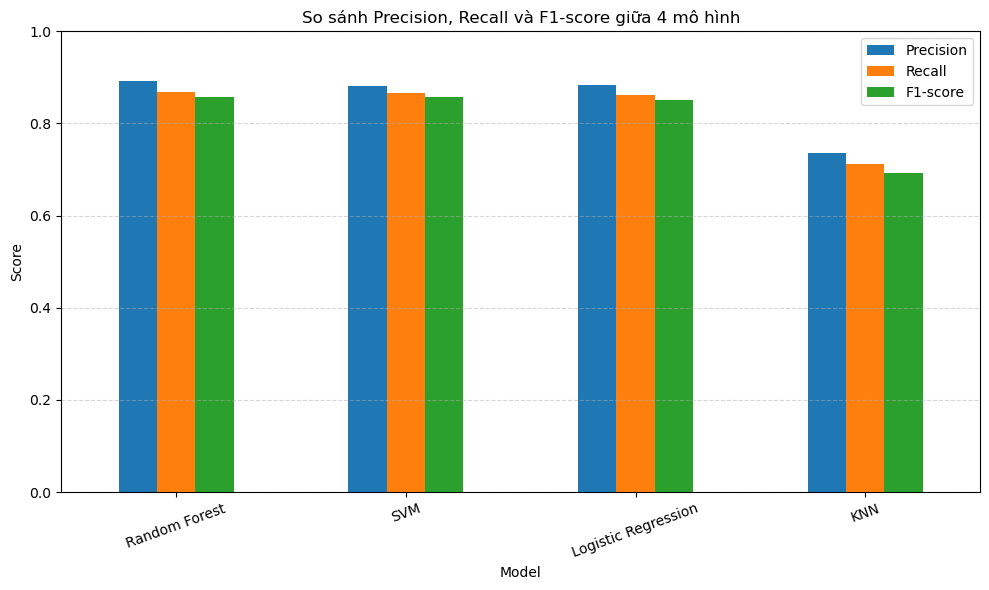

Đã lưu biểu đồ: comparison_results\comparison_precision_recall_f1.png


In [6]:
# Cell 6: Vẽ biểu đồ gộp Precision, Recall, F1-score

plot_df = comparison_df.set_index("Model")[["Precision", "Recall", "F1-score"]]

ax = plot_df.plot(kind="bar", figsize=(10, 6))

plt.title("So sánh Precision, Recall và F1-score giữa 4 mô hình")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()

bar_chart_path = OUTPUT_DIR / "comparison_precision_recall_f1.png"
plt.savefig(bar_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Đã lưu biểu đồ:", bar_chart_path)


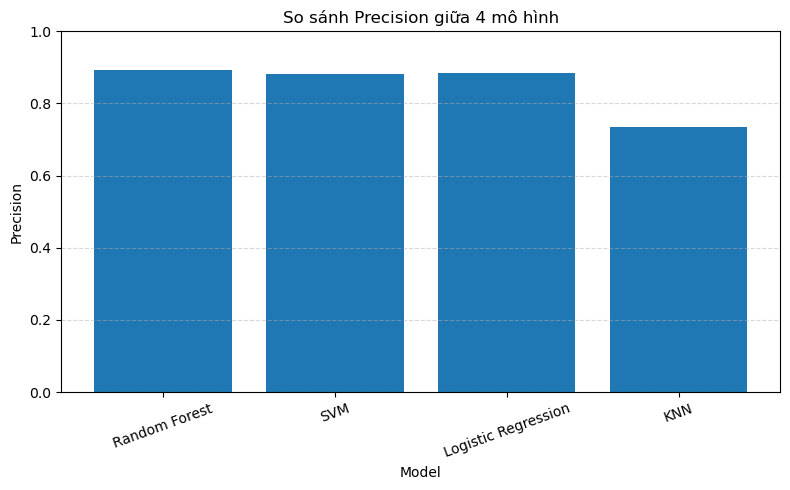

Đã lưu: comparison_results\comparison_precision.png


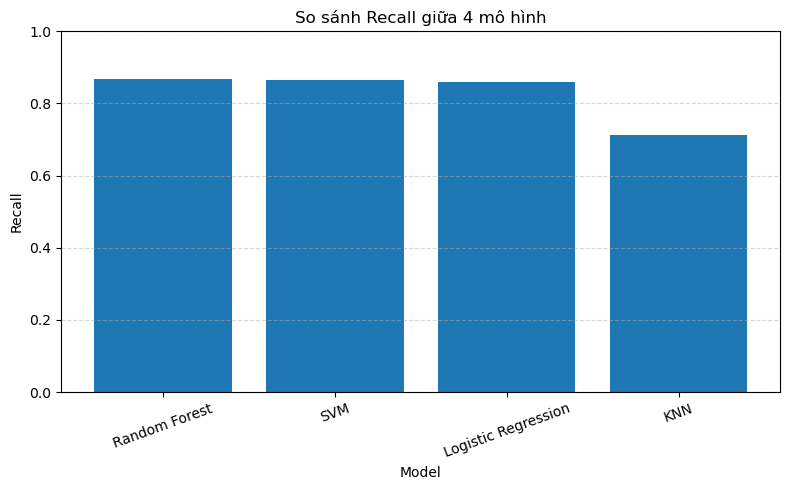

Đã lưu: comparison_results\comparison_recall.png


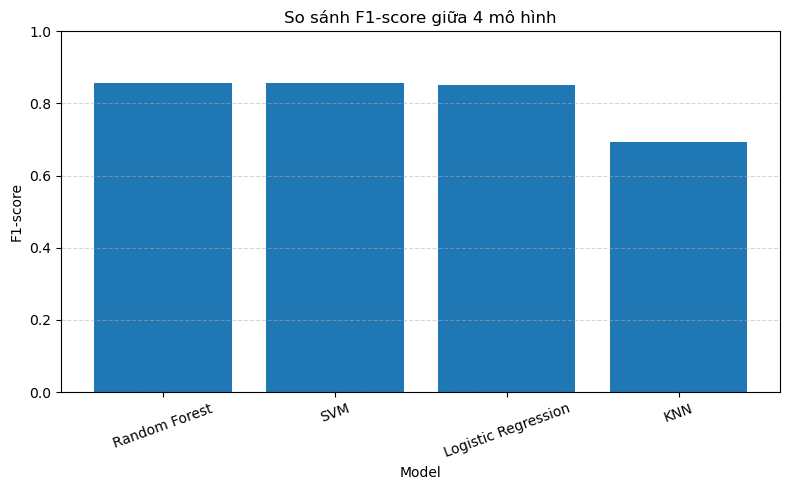

Đã lưu: comparison_results\comparison_f1_score.png


In [ ]:
# Cell 7: Vẽ riêng từng chỉ số 

metrics_to_plot = ["Precision", "Recall", "F1-score"]

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    plt.bar(comparison_df["Model"], comparison_df[metric])

    plt.title(f"So sánh {metric} giữa 4 mô hình")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.xticks(rotation=20)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()

    save_path = OUTPUT_DIR / f"comparison_{metric.replace('-', '_').lower()}.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Đã lưu:", save_path)


In [8]:
# Cell 8: Hiển thị confusion matrix của từng model nếu có file ảnh

for model_name in comparison_df["Model"]:
    img_path = confusion_paths.get(model_name)

    if img_path is None or not Path(img_path).exists():
        print(f"Không tìm thấy confusion matrix của {model_name}")
        continue

    img = Image.open(img_path)

    plt.figure(figsize=(6, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()


Không tìm thấy confusion matrix của Random Forest
Không tìm thấy confusion matrix của SVM
Không tìm thấy confusion matrix của Logistic Regression
Không tìm thấy confusion matrix của KNN


In [9]:
# Cell 9: Hiển thị classification report chi tiết từng model

for model_name, report_df in full_reports.items():
    print("\n" + "=" * 60)
    print(f"Classification Report - {model_name}")
    print("=" * 60)
    display(report_df)



Classification Report - KNN


,precision,recall,f1-score,support
bad,0.584718,0.911917,0.712551,579.000000
good,0.773529,0.416139,0.541152,632.000000
shell,0.847589,0.807407,0.827011,675.000000
accuracy,0.708378,0.708378,0.708378,0.708378
macro avg,0.735279,0.711821,0.693571,1886.000000
weighted avg,0.742070,0.708378,0.696080,1886.000000



Classification Report - SVM


,precision,recall,f1-score,support
bad,0.724841,0.982729,0.834311,579.000000
good,0.929134,0.933544,0.931334,632.000000
shell,0.987124,0.681481,0.806310,675.000000
accuracy,0.858431,0.858431,0.858431,0.858431
macro avg,0.880366,0.865918,0.857318,1886.000000
weighted avg,0.887171,0.858431,0.856802,1886.000000



Classification Report - Random Forest


,precision,recall,f1-score,support
bad,0.691839,0.981002,0.811429,579.000000
good,0.982839,0.996835,0.989788,632.000000
shell,1.000000,0.628148,0.771611,675.000000
accuracy,0.860021,0.860021,0.860021,0.860021
macro avg,0.891560,0.868662,0.857609,1886.000000
weighted avg,0.899644,0.860021,0.856946,1886.000000



Classification Report - Logistic Regression


,precision,recall,f1-score,support
bad,0.686675,0.987910,0.810198,579.000000
good,0.986949,0.957278,0.971888,632.000000
shell,0.977273,0.637037,0.771300,675.000000
accuracy,0.852068,0.852068,0.852068,0.852068
macro avg,0.883632,0.860742,0.851129,1886.000000
weighted avg,0.891302,0.852068,0.850459,1886.000000


In [10]:
# Cell 10: Tự động kết luận model tốt nhất theo Macro F1-score

best_model = comparison_df.iloc[0]

print("Mô hình có Macro F1-score cao nhất:")
print(f"- Model: {best_model['Model']}")
print(f"- Precision: {best_model['Precision']:.4f}")
print(f"- Recall: {best_model['Recall']:.4f}")
print(f"- F1-score: {best_model['F1-score']:.4f}")

summary_text = f"""
Kết quả so sánh cho thấy mô hình {best_model['Model']} đạt Macro F1-score cao nhất,
với Precision = {best_model['Precision']:.4f}, Recall = {best_model['Recall']:.4f}
và F1-score = {best_model['F1-score']:.4f}. Do đó, trong phạm vi 4 mô hình học máy
truyền thống được thử nghiệm, {best_model['Model']} cho hiệu quả phân loại tốt nhất
trên tập kiểm thử.
"""

summary_path = OUTPUT_DIR / "summary_best_model.txt"
summary_path.write_text(summary_text, encoding="utf-8")

print("\nNội dung nhận xét:")
print(summary_text)
print("Đã lưu nhận xét:", summary_path)


Mô hình có Macro F1-score cao nhất:
- Model: Random Forest
- Precision: 0.8916
- Recall: 0.8687
- F1-score: 0.8576

Nội dung nhận xét:

Kết quả so sánh cho thấy mô hình Random Forest đạt Macro F1-score cao nhất,
với Precision = 0.8916, Recall = 0.8687
và F1-score = 0.8576. Do đó, trong phạm vi 4 mô hình học máy
truyền thống được thử nghiệm, Random Forest cho hiệu quả phân loại tốt nhất
trên tập kiểm thử.

Đã lưu nhận xét: comparison_results\summary_best_model.txt
